In [228]:
# AUTOGENERATED! DO NOT EDIT! File to edit: ../../nbs/dvc.experiment.ipynb.

# %% auto 0
__all__ = ["parse_params", "parse_metrics", "parse_experiment", "parse_experiments", "load_experiments"]

# %% ../../nbs/dvc.experiment.ipynb 3
import json
from typing import Generator


# %% ../../nbs/dvc.experiment.ipynb 4
def parse_params(record):
    params_node = record.get("data", {}).get("params", {})
    params = {}
    for k, v in params_node.items():
        params.update(v.get("data", {}))
    return params


def parse_metrics(record):
    metrics_node = record.get("data", {}).get("metrics", {})
    metrics = {}
    for k, v in metrics_node.items():
        metrics.update(v.get("data", {}))
    return metrics


def parse_experiment(record):
    return {
        "id": record["rev"],
        "name": record["name"],
        "params": parse_params(record),
        "metrics": parse_metrics(record),
    }


def parse_experiments(data: list[dict]) -> Generator[dict, None, None]:
    for node in data:
        if node.get("error"):
            continue
        commit = node.get("rev")
        if experiments := (node.get("experiments") or []):
            for experiment in experiments:
                for rev in experiment.get("revs") or []:
                    if not rev.get("error"):
                        yield {"commit": commit, **parse_experiment(rev)}
        else:
            yield {"commit": commit, **parse_experiment(node)}


def load_experiments(json_filepath):
    with open(json_filepath, "r") as f:
        data = json.load(f)
    return list(parse_experiments(data))


In [229]:
import itertools
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn

In [230]:
def sorted_tuple(x):
    return tuple(sorted(x))

In [231]:
def jprint(obj):
    print(json.dumps(obj, indent=2))

In [232]:
filepaths = list(Path("../tmp/experiments-new/").glob("*.json"))
experiments = [exp for fp in filepaths for exp in load_experiments(fp)]
print(f"{len(experiments)} experiments")
jprint(next(iter(experiments), None))

40 experiments
{
  "commit": "workspace",
  "id": "workspace",
  "name": null,
  "params": {
    "dataset": {
      "path": "bdsaglam/musique-mini",
      "name": "answerable",
      "split": "validation"
    },
    "model": {
      "path": "Qwen/Qwen2.5-1.5B-Instruct",
      "temperature": 0.3,
      "top_p": 0.95
    },
    "retriever": {
      "name": "semantic",
      "top_k": 2
    },
    "run": 1,
    "devices": 0
  },
  "metrics": {
    "exact_match": 0.36333333333333334,
    "f1": 0.4574181341534283
  }
}


In [233]:
df = pd.json_normalize(experiments)
df.drop(columns=['params.devices'], inplace=True)
print(f"{len(df)} experiments before preprocessing")
df.head()

40 experiments before preprocessing


,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.path,params.model.temperature,params.model.top_p,params.retriever.name,params.retriever.top_k,params.run,metrics.exact_match,metrics.f1
0,workspace,workspace,None,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,semantic,2,1,0.363333,0.457418
1,e6b8701a808479bb748e35ff3819b74f3d605bb5,9be0c072958400ed8c90fbd01d6a0ec4fcc89df5,regal-agas,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,hybrid,2,1,0.003333,0.014063
2,e6b8701a808479bb748e35ff3819b74f3d605bb5,8330696119846e44f5e2d5f82de0f9a24bc483c4,riant-sley,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,lexical,2,1,0.330000,0.421276
3,e6b8701a808479bb748e35ff3819b74f3d605bb5,87ae8bb2011147337cdf0169e4525033dd4c0954,print-size,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,hybrid,3,1,0.353333,0.449422
4,workspace,workspace,None,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,semantic,2,1,0.003333,0.014063


In [234]:
param_cols = [col for col in df.columns if col.startswith("params.")]
metric_cols = [col for col in df.columns if col.startswith("metrics.")]

In [235]:
if len(df):
    df['params.model.temperature'] = df['params.model.temperature'].astype(float).map(lambda x: round(x, 2))
    df['params.model.top_p'] = df['params.model.top_p'].astype(float).map(lambda x: round(x, 2))

In [236]:
if len(df):
    df.dropna(subset=param_cols + metric_cols, inplace=True, how="any")
    df.drop_duplicates(subset=param_cols, inplace=True, keep='last')

    print(f"{len(df)} experiments after preprocessing")
df.head()

34 experiments after preprocessing


,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.path,params.model.temperature,params.model.top_p,params.retriever.name,params.retriever.top_k,params.run,metrics.exact_match,metrics.f1
1,e6b8701a808479bb748e35ff3819b74f3d605bb5,9be0c072958400ed8c90fbd01d6a0ec4fcc89df5,regal-agas,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,hybrid,2,1,0.003333,0.014063
2,e6b8701a808479bb748e35ff3819b74f3d605bb5,8330696119846e44f5e2d5f82de0f9a24bc483c4,riant-sley,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,lexical,2,1,0.330000,0.421276
3,e6b8701a808479bb748e35ff3819b74f3d605bb5,87ae8bb2011147337cdf0169e4525033dd4c0954,print-size,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,hybrid,3,1,0.353333,0.449422
8,4dfc4975fe4745eb0fa3084179089047091b3661,4dfc4975fe4745eb0fa3084179089047091b3661,None,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,semantic,2,1,0.003333,0.014063
9,d1ab4a826ad5d4645db54284d02b5d7f89060447,4ae9182a5b4ddcabe96e741f2e146023468eb7fc,faint-gimp,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,lexical,2,1,0.300000,0.396718


In [237]:
for col in param_cols:
    values = list(df[col].unique())
    print(f"- {col}: {values}")
    print()

- params.dataset.path: ['bdsaglam/musique-mini']

- params.dataset.name: ['answerable']

- params.dataset.split: ['validation']

- params.model.path: ['/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged', 'Qwen/Qwen2.5-1.5B-Instruct', '/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-musique-scaled-merged', 'bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique', 'Qwen/Qwen2.5-7B-Instruct', 'meta-llama/Llama-3.1-8B-Instruct']

- params.model.temperature: [0.5, 0.3]

- params.model.top_p: [0.95]

- params.retriever.name: ['hybrid', 'lexical', 'semantic']

- params.retriever.top_k: [2, 3, 1]

- params.run: [1]



In [238]:
df.to_json('exps.jsonl', orient='records', lines=True)

## Setup remaining experiments

In [239]:
df = pd.read_json('exps.jsonl', orient='records', lines=True)

In [240]:
def produce_experiment_configs(common_params, varying_params):
    # Generate all possible combinations of parameters
    varying_params = {**common_params, **varying_params}
    keys = varying_params.keys()
    values = varying_params.values()
    for instance in itertools.product(*values):
        yield dict(zip(keys, instance))

In [241]:
def produce_all_experiment_configs(common_params: dict, varying_params_list: list[dict]):
    for params in varying_params_list:
        for exp_config in produce_experiment_configs(common_params, params):
            yield exp_config

In [242]:
common_params = {
    "params.dataset.path": ["bdsaglam/musique-mini"],
    "params.dataset.name": ["answerable"],
    "params.dataset.split": ['validation'],
    "params.model.path": [
        "Qwen/Qwen2.5-1.5B-Instruct",
        "Qwen/Qwen2.5-7B-Instruct",
        "meta-llama/Llama-3.1-8B-Instruct",
        "bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique",
        "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged",
        "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-musique-scaled-merged",
    ],
    "params.model.temperature": [
        0.5,
    ],
    "params.model.top_p": [
        0.95,
    ],
    "params.retriever.name": [
        "semantic",
        "lexical",
        "hybrid",
    ],
    "params.retriever.top_k": [
        1,
        2,
        3,
    ],
}

In [243]:
varying_params_list = [
    {
        "params.run": [
            1,
            # 2,
            # 3,
        ],
    }
]

In [244]:
exp_configs = list(produce_all_experiment_configs(common_params, varying_params_list))
target_params = list(exp_configs[0].keys())
print(f"{len(exp_configs)} experiment configurations")
print(target_params)

54 experiment configurations
['params.dataset.path', 'params.dataset.name', 'params.dataset.split', 'params.model.path', 'params.model.temperature', 'params.model.top_p', 'params.retriever.name', 'params.retriever.top_k', 'params.run']


In [245]:
def preprocess_config(config):
    return {k: round(v, 2) if isinstance(v, float) else v for k, v in config.items()}

In [246]:
if len(df):
    existing_configs = [preprocess_config(config) for config in df[target_params].to_dict(orient="records")]
    existing_configs[0]
else:
    existing_configs = []

print("Existing exps:", len(existing_configs))

Existing exps: 34


In [247]:
# find the missing configurations
missing_configs = [
    preprocess_config(dict(kv))
    for kv in list(
        {tuple(sorted(config.items())) for config in exp_configs}
        - {tuple(sorted(config.items())) for config in existing_configs}
    )
]
print(f"{len(missing_configs)} missing configurations")

21 missing configurations


In [248]:
def make_command(exp_config):
    lines = ["dvc exp run --queue"]
    for target_param in target_params:
        arg_name = target_param.split(".", 1)[-1]
        arg_value = exp_config[target_param]
        lines.append(f"-S {arg_name}='{arg_value}'")

    command = " \\\n    ".join(lines)
    return command

In [249]:
with open("run.sh", "w") as f:
    f.write("#!/bin/sh\n\n")
    for i,exp_config in enumerate(missing_configs):
        command = make_command(exp_config)
        device = i % 4
        command += f" \\\n    -S devices='{device}'"
        f.write(command)
        f.write("\n\n")

In [250]:
next(iter(existing_configs), None)

{'params.dataset.path': 'bdsaglam/musique-mini',
 'params.dataset.name': 'answerable',
 'params.dataset.split': 'validation',
 'params.model.path': '/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged',
 'params.model.temperature': 0.5,
 'params.model.top_p': 0.95,
 'params.retriever.name': 'hybrid',
 'params.retriever.top_k': 2,
 'params.run': 1}

In [251]:
next(iter(missing_configs), None)

{'params.dataset.name': 'answerable',
 'params.dataset.path': 'bdsaglam/musique-mini',
 'params.dataset.split': 'validation',
 'params.model.path': '/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged',
 'params.model.temperature': 0.5,
 'params.model.top_p': 0.95,
 'params.retriever.name': 'hybrid',
 'params.retriever.top_k': 1,
 'params.run': 1}

## Inspect

In [252]:
target_params = [*param_cols]
target_params.remove('params.run')

In [253]:
df['params.model.name'] = df['params.model.path'].map(lambda x: x.rsplit('/', 1)[-1])
df['params.fine_tuning'] = df['params.model.name'].map(lambda x: 'GRPO' if 'ragent' in x else 'None')
df['params.model.base'] = df['params.model.name'].map(lambda x: x.rsplit('-ragent')[0])
# extract the model size from the model name, e.g. Qwen/Qwen2.5-1.5B-Instruct -> 1.5B
df['params.model.size'] = df['params.model.name'].str.extract(r'-([0-9.]+)B-').map(float)

In [254]:
df[
    [
        "params.model.name",
        "params.model.size",
        "params.fine_tuning",
        "params.retriever.name",
        "params.retriever.top_k",
        "metrics.exact_match",
        "metrics.f1",
    ]
].sort_values(by="metrics.f1", ascending=False)

,params.model.name,params.model.size,params.fine_tuning,params.retriever.name,params.retriever.top_k,metrics.exact_match,metrics.f1
2,Llama-3.1-8B-Instruct-ragent-grpo-musique-merged,8.0,GRPO,hybrid,3,0.353333,0.449422
23,Llama-3.1-8B-Instruct-ragent-grpo-musique-scal...,8.0,GRPO,hybrid,3,0.336667,0.429930
33,Llama-3.1-8B-Instruct-ragent-grpo-musique-scal...,8.0,GRPO,hybrid,2,0.313333,0.424789
1,Llama-3.1-8B-Instruct-ragent-grpo-musique-merged,8.0,GRPO,lexical,2,0.330000,0.421276
12,Llama-3.1-8B-Instruct-ragent-grpo-musique-scal...,8.0,GRPO,hybrid,1,0.326667,0.417899
4,Llama-3.1-8B-Instruct-ragent-grpo-musique-scal...,8.0,GRPO,lexical,2,0.300000,0.396718
22,Llama-3.1-8B-Instruct-ragent-grpo-musique-scal...,8.0,GRPO,lexical,3,0.303333,0.379572
30,Llama-3.1-8B-Instruct,8.0,None,hybrid,1,0.220000,0.298185
16,Llama-3.1-8B-Instruct,8.0,None,hybrid,2,0.236667,0.293123
20,Qwen2.5-7B-Instruct,7.0,None,hybrid,1,0.210000,0.283739


In [255]:
def scatter_plot(df):
    # Create publication-quality plot comparing model size vs F1 score
    plt.style.use('seaborn-v0_8')  # Use the updated seaborn style name
    plt.figure(figsize=(12, 6))

    # Customize appearance
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Model Size (Billion Parameters)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.title('Model Performance vs Size', fontsize=14, pad=15)

    # Add retriever type as color
    colors = {'hybrid': 'C0', 'lexical': 'C1', 'semantic': 'C2'}
    for retriever in colors:
        mask = df['params.retriever.name'] == retriever
        
        # Plot points
        plt.scatter(df[mask]['params.model.size'], 
                df[mask]['metrics.f1'],
                label=retriever.capitalize(),
                alpha=0.7,
                s=100,
                c=colors[retriever])
        
        # Add model names as annotations
        for idx in df[mask].index:
            model_name = df.loc[idx, 'params.model.base'] + "-" + df.loc[idx, 'params.fine_tuning']
            plt.annotate(model_name,
                        (df.loc[idx, 'params.model.size'], 
                        df.loc[idx, 'metrics.f1']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8)

    plt.legend(title='Retriever Type', title_fontsize=10)

    # Adjust layout and style
    plt.tight_layout()
    plt.show()



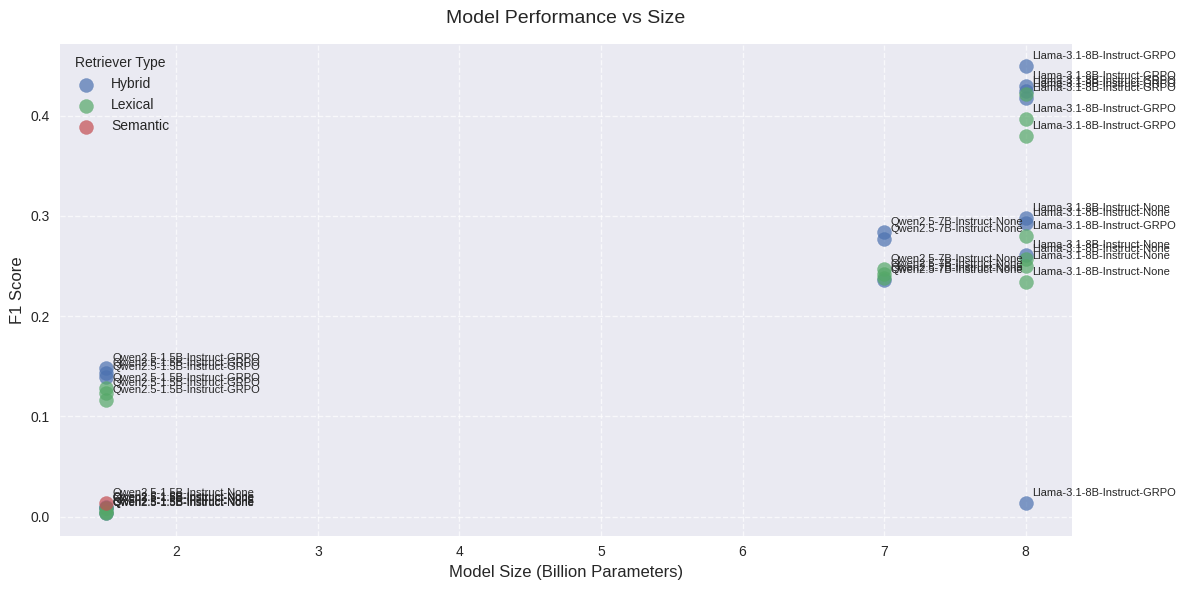

In [256]:
scatter_plot(df)

In [257]:
def plot_model_size_vs_f1(df):
    """Create a publication-quality scatter plot comparing model size vs F1 score."""
    # Set style and figure size
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    
    # Customize appearance
    ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_xlabel("Model Size (Billion Parameters)", fontsize=12, fontweight="bold")
    ax.set_ylabel("F1 Score", fontsize=12, fontweight="bold")
    ax.set_title("Language Model Performance by Parameter Count", 
                fontsize=14, pad=15, fontweight="bold")

    # Define colors and markers
    colors = {"None": "#2E86C1", "GRPO": "#E74C3C"}
    markers = {"None": "o", "GRPO": "^"}

    for fine_tuning in ["None", "GRPO"]:
        mask = df["params.fine_tuning"] == fine_tuning
        label = "Base Model" if fine_tuning == "None" else "GRPO Fine-tuned"

        # Plot points
        ax.scatter(
            df[mask]["params.model.size"],
            df[mask]["metrics.f1"],
            label=label,
            alpha=0.9,
            s=120,
            c=colors[fine_tuning],
            marker=markers[fine_tuning],
            edgecolor="white",
            linewidth=1,
            zorder=2
        )

        # Add model name annotations
        for idx in df[mask].index:
            label = df.loc[idx, "params.model.base"].replace("Instruct", "").strip("-")
            plt.annotate(
                label,
                (df.loc[idx, "params.model.size"], df.loc[idx, "metrics.f1"]),
                xytext=(7, 7),
                textcoords="offset points",
                fontsize=9,
                alpha=0.8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1)
            )

    # Customize legend
    ax.legend(
        title="Model Type",
        title_fontsize=10,
        fontsize=10,
        framealpha=0.9,
        edgecolor="none",
        loc="upper left"
    )

    # Set axis limits with padding
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    # Format axis ticks
    ax.tick_params(axis="both", which="major", labelsize=10)
    
    plt.tight_layout()
    plt.show()


In [258]:
def aggregate_best_models(df, by: list[str] = ["params.model.base", "params.fine_tuning"]):
    # Group by model base and fine tuning method
    grouped = df.groupby(by)

    # Get columns of interest
    columns = [
        "params.model.base",
        "params.model.size", 
        "params.fine_tuning",
        "params.retriever.name",
        "params.retriever.top_k",
        "metrics.f1",
    ]

    # For each group, select the row with highest F1 score
    return (
        grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]
        .reset_index(drop=True)
        .sort_values(by="metrics.f1", ascending=False)
    )

In [259]:
best_df = aggregate_best_models(df)
best_df

/tmp/ipykernel_1591559/3758175697.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]


,params.model.base,params.model.size,params.fine_tuning,params.retriever.name,params.retriever.top_k,metrics.f1
0,Llama-3.1-8B-Instruct,8.0,GRPO,hybrid,3,0.449422
1,Llama-3.1-8B-Instruct,8.0,None,hybrid,1,0.298185
4,Qwen2.5-7B-Instruct,7.0,None,hybrid,1,0.283739
2,Qwen2.5-1.5B-Instruct,1.5,GRPO,hybrid,2,0.148640
3,Qwen2.5-1.5B-Instruct,1.5,None,semantic,2,0.014063


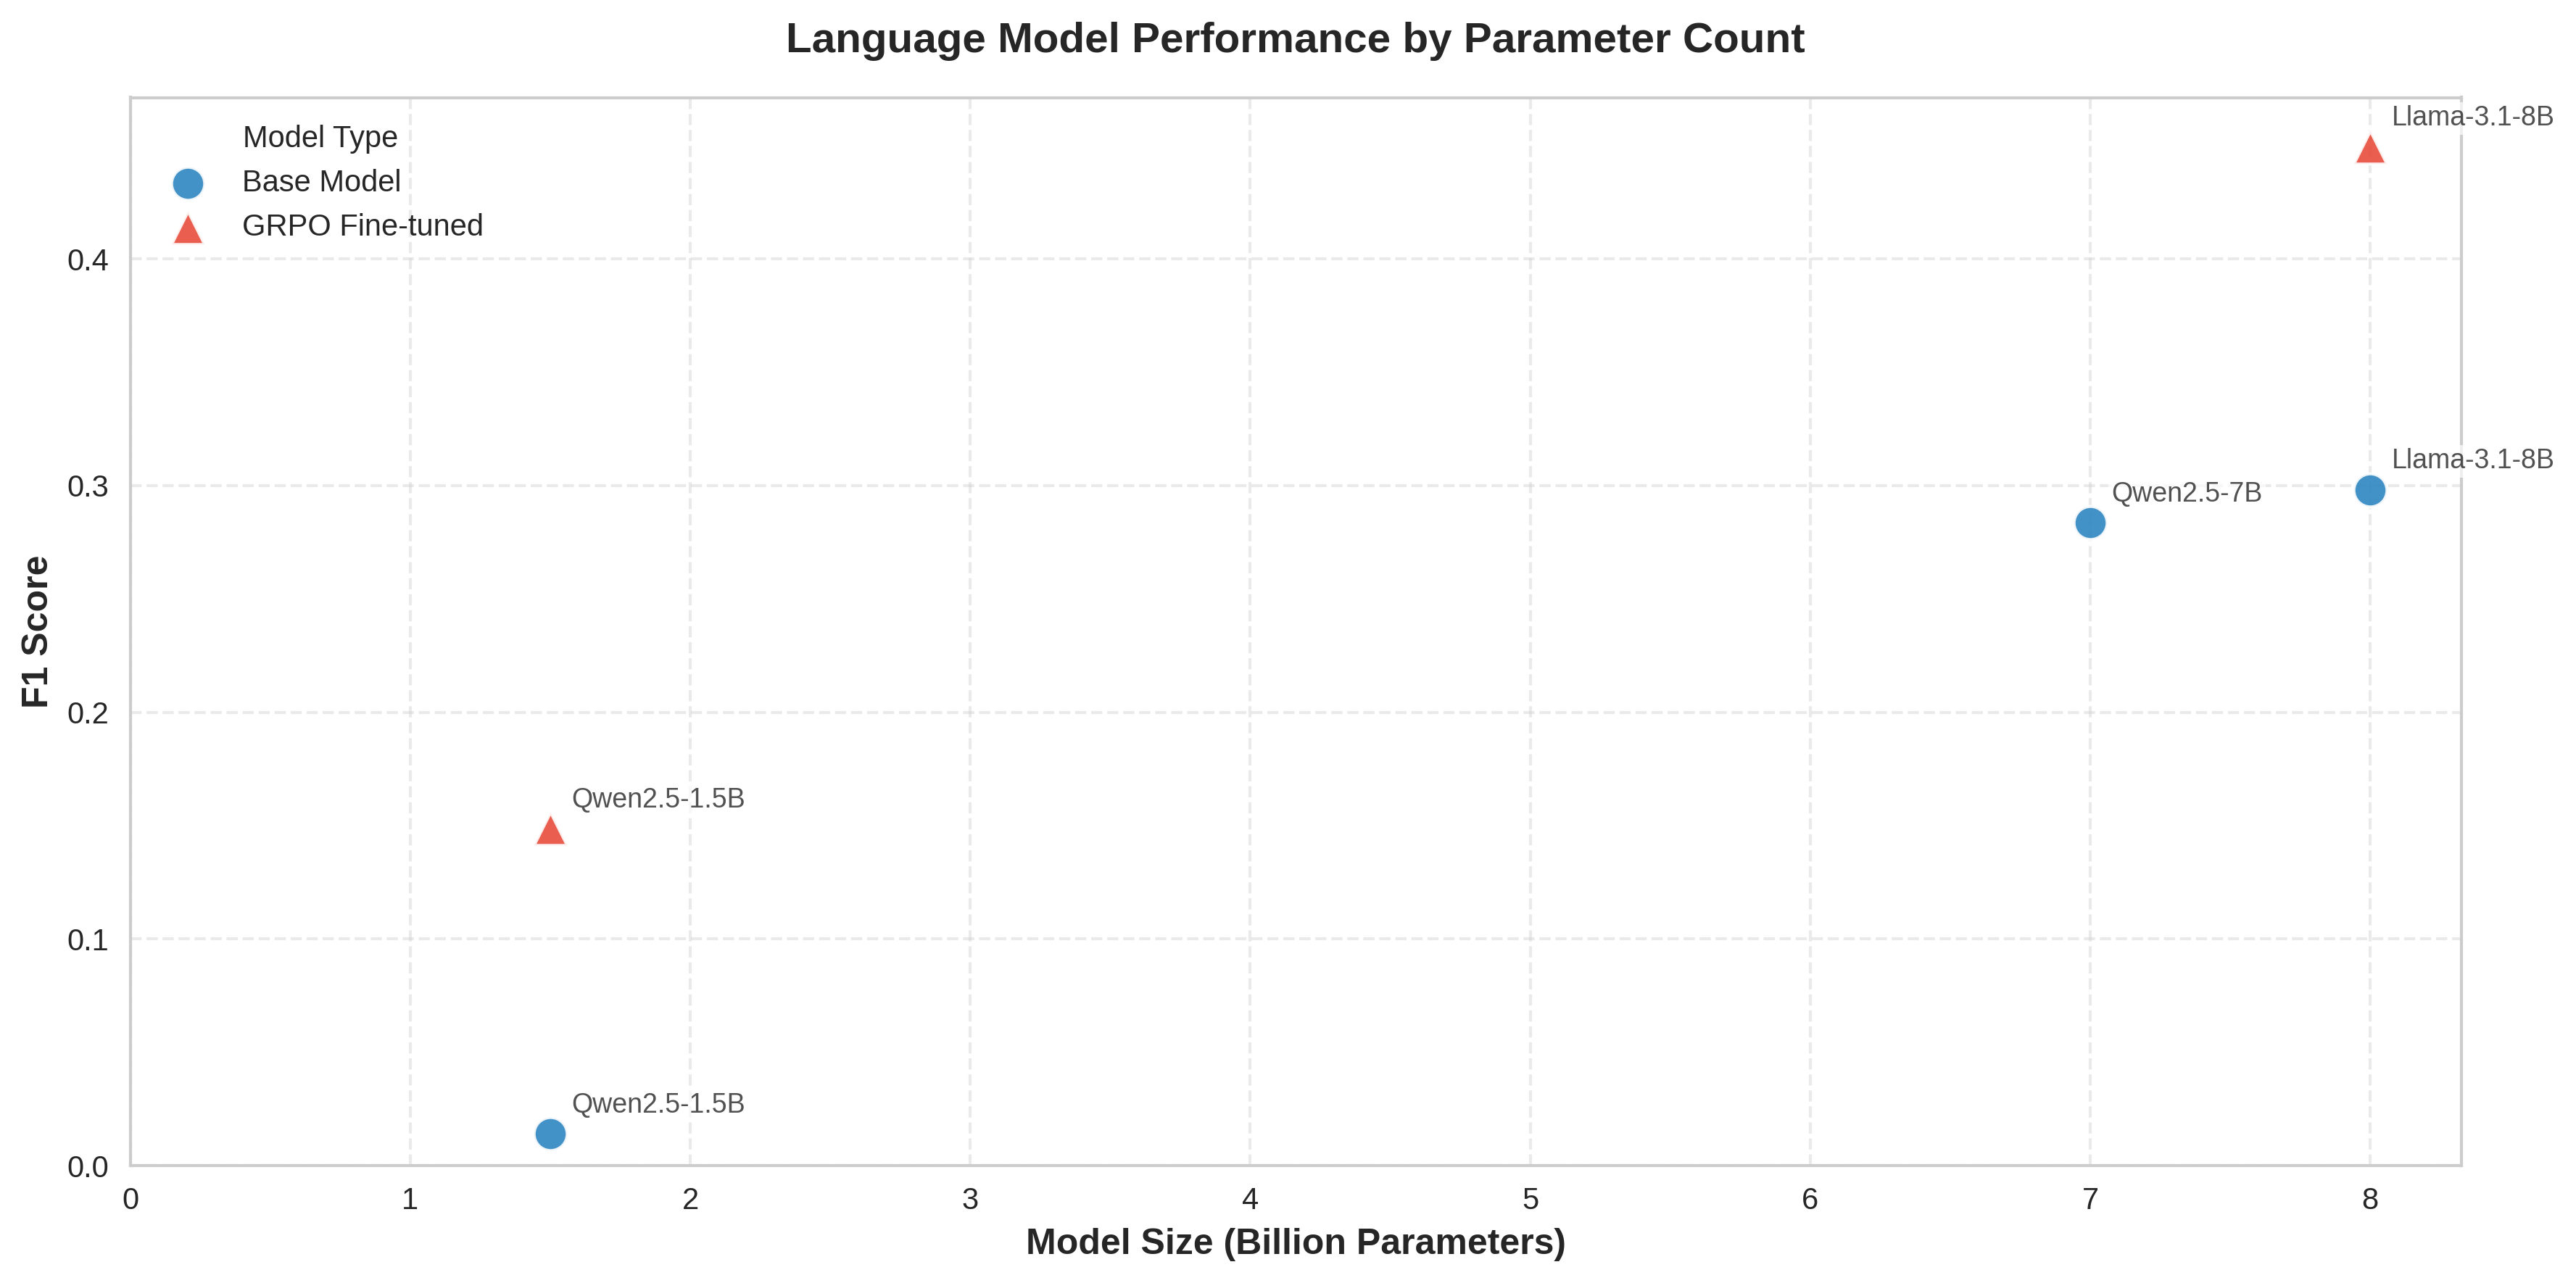

In [260]:
plot_model_size_vs_f1(best_df)

In [261]:
hybrid_1_df = df[(df["params.retriever.name"] == "hybrid") & (df["params.retriever.top_k"] == 1)]
hybrid_1_df

,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.path,params.model.temperature,params.model.top_p,params.retriever.name,params.retriever.top_k,params.run,metrics.exact_match,metrics.f1,params.model.name,params.fine_tuning,params.model.base,params.model.size
12,d1ab4a826ad5d4645db54284d02b5d7f89060447,dca57d8634e7b292ddcd4b730def644db88d23e7,slack-holy,bdsaglam/musique-mini,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,hybrid,1,1,0.326667,0.417899,Llama-3.1-8B-Instruct-ragent-grpo-musique-scal...,GRPO,Llama-3.1-8B-Instruct,8.0
20,d1ab4a826ad5d4645db54284d02b5d7f89060447,c1bd96d598098787a9deb25c8bcd0816c28a8983,stung-suqs,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-7B-Instruct,0.5,0.95,hybrid,1,1,0.210000,0.283739,Qwen2.5-7B-Instruct,None,Qwen2.5-7B-Instruct,7.0
28,d1ab4a826ad5d4645db54284d02b5d7f89060447,17a894cc4f5fccf38b694c6c22d4919c5304f3ec,pious-hymn,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.5,0.95,hybrid,1,1,0.003333,0.003333,Qwen2.5-1.5B-Instruct,None,Qwen2.5-1.5B-Instruct,1.5
29,d1ab4a826ad5d4645db54284d02b5d7f89060447,cde227528c82f44622c4e6640da3d25fef52f59a,campy-flus,bdsaglam/musique-mini,answerable,validation,bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique,0.5,0.95,hybrid,1,1,0.083333,0.143222,Qwen2.5-1.5B-Instruct-ragent-musique,GRPO,Qwen2.5-1.5B-Instruct,1.5
30,d1ab4a826ad5d4645db54284d02b5d7f89060447,f2a52ea32783e0390a907c64afb07e5ce37d3a24,noisy-sinh,bdsaglam/musique-mini,answerable,validation,meta-llama/Llama-3.1-8B-Instruct,0.5,0.95,hybrid,1,1,0.220000,0.298185,Llama-3.1-8B-Instruct,None,Llama-3.1-8B-Instruct,8.0


In [262]:
best_hybrid_1_df = aggregate_best_models(hybrid_1_df)
best_hybrid_1_df

/tmp/ipykernel_1591559/3758175697.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]


,params.model.base,params.model.size,params.fine_tuning,params.retriever.name,params.retriever.top_k,metrics.f1
0,Llama-3.1-8B-Instruct,8.0,GRPO,hybrid,1,0.417899
1,Llama-3.1-8B-Instruct,8.0,None,hybrid,1,0.298185
4,Qwen2.5-7B-Instruct,7.0,None,hybrid,1,0.283739
2,Qwen2.5-1.5B-Instruct,1.5,GRPO,hybrid,1,0.143222
3,Qwen2.5-1.5B-Instruct,1.5,None,hybrid,1,0.003333


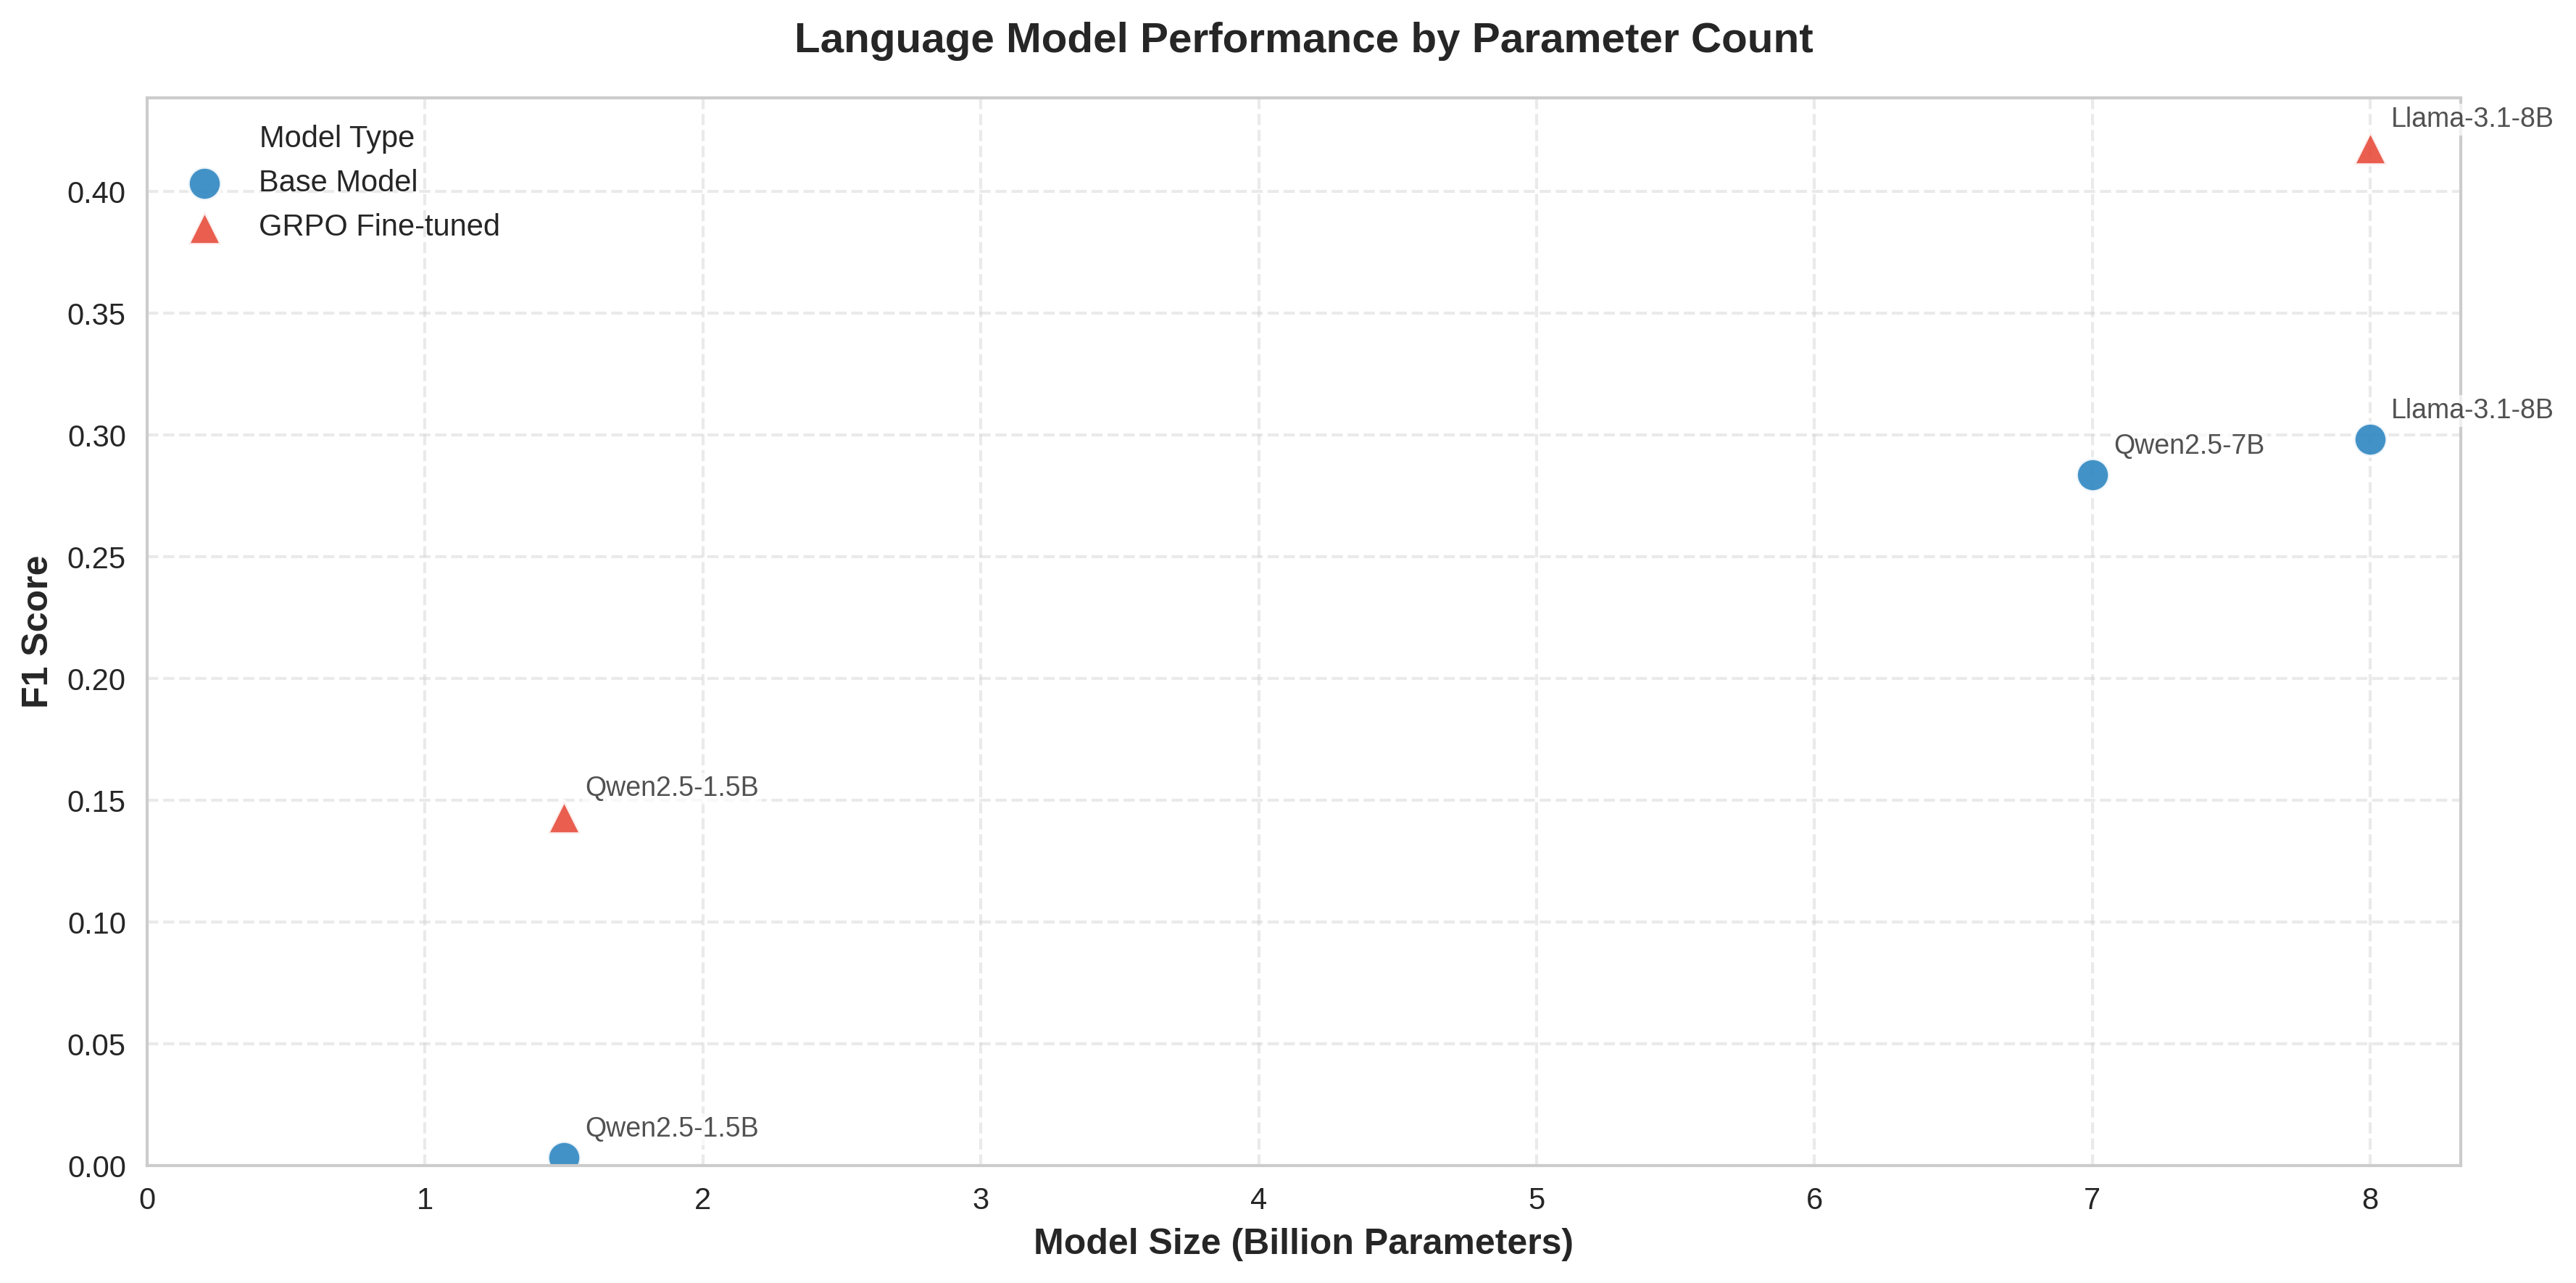

In [263]:
plot_model_size_vs_f1(best_hybrid_1_df)

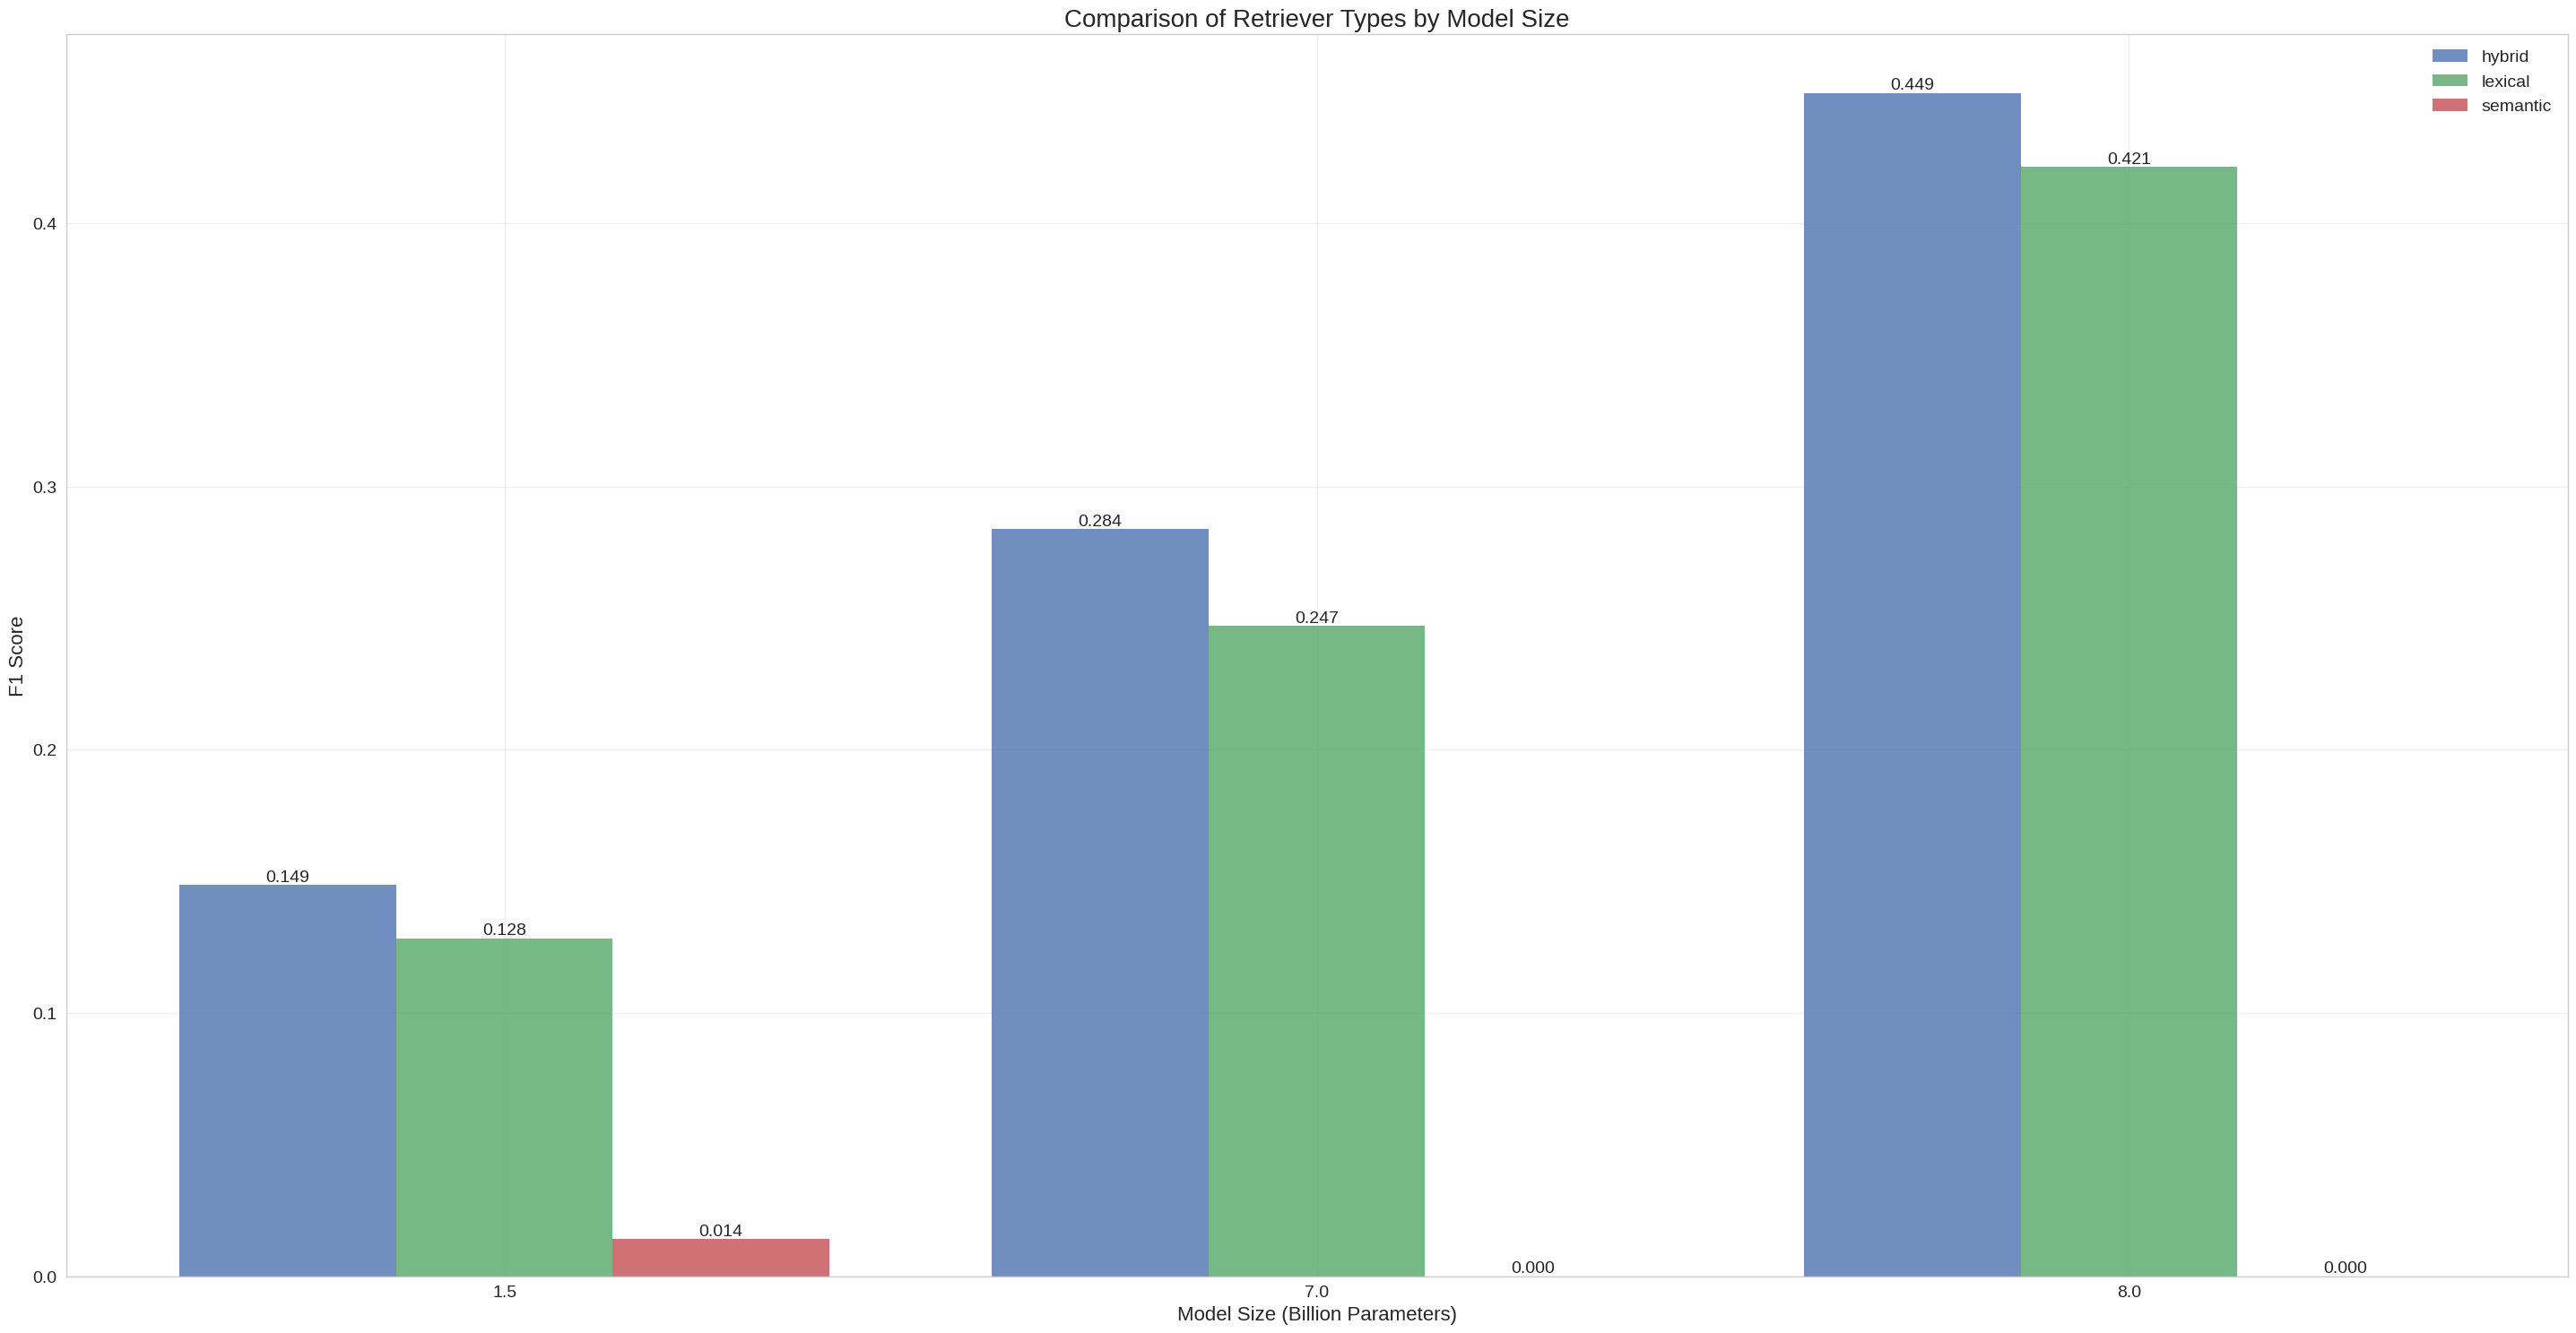

In [264]:
import numpy as np


def plot_retriever_comparison(df):
    plt.figure(figsize=(36, 18))

    # Group by model size and retriever type
    grouped = df.groupby(["params.model.size", "params.retriever.name"])

    # Get best results for each group
    retriever_df = grouped.agg({"metrics.f1": "max"}).reset_index()

    # Get unique model sizes and retriever types
    model_sizes = sorted(df["params.model.size"].unique())
    retriever_types = sorted(df["params.retriever.name"].unique())

    # Set up bar positions
    x = np.arange(len(model_sizes))
    width = 0.8 / len(retriever_types)

    # Create grouped bar plot
    for i, retriever in enumerate(retriever_types):
        data = retriever_df[retriever_df["params.retriever.name"] == retriever]
        heights = [
            data[data["params.model.size"] == size]["metrics.f1"].values[0]
            if len(data[data["params.model.size"] == size]) > 0
            else 0
            for size in model_sizes
        ]

        pos = x + i * width - (len(retriever_types) - 1) * width / 2
        bars = plt.bar(pos, heights, width, label=retriever, alpha=0.8)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom", fontsize=14)

    # Customize plot
    plt.title("Comparison of Retriever Types by Model Size", fontsize=20)
    plt.xlabel("Model Size (Billion Parameters)", fontsize=16)
    plt.ylabel("F1 Score", fontsize=16)
    plt.xticks(x, model_sizes, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()


plot_retriever_comparison(df)
